# CLC for Distribution Topology Generation

This notebook compares two approaches to generating distribution-scale grid **topologies**:

| Method | Origin | Structure | Key algorithm |
|---|---|---|---|
| **CLC (Chung-Lu Chain)** | Transmission-specific | Meshed / weakly meshed | Degree-sequence + diameter-constrained random graph |
| **Schweitzer et al. 2017** | Distribution-specific | Strictly radial (tree) | Hop-distance + bottom-up predecessor matching |

We compare them at the **same scale** (~50 nodes) to highlight the topological differences.  
Only topology is generated — no generation, load, cable type, or cable length assignments.

In [1]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

from powergrid_synth import (
    PowerGridGenerator,
    InputConfigurator,
    GridVisualizer,
    GraphComparator,
    DistributionGrid,
)
from powergrid_synth.distribution import (
    SchweetzerFeederGenerator,
    DistributionSynthParams,
    validate_tree,
    compute_emergent_properties,
)
from powergrid_synth.core.analysis import GridAnalyzer

viz = GridVisualizer()
SEED = 42
N_NODES = 50

## 1  Distribution-specific method (Schweitzer)

The Schweitzer algorithm builds a **radial tree** by:
1. Assigning hop distances from a Negative Binomial distribution
2. Sampling target degrees from a bimodal Gamma mixture
3. Connecting nodes bottom-up to the predecessor with the largest degree deficit

We disable cable type/length assignment to isolate pure topology.

In [2]:
# --- Schweitzer feeder (topology only) ---
dist_gen = SchweetzerFeederGenerator(seed=SEED)
G_dist_raw = dist_gen.generate_feeder(
    n_nodes=N_NODES,
    total_load_mw=2.5,       # required but irrelevant for topology
    total_gen_mw=0.0,
    assign_cable_types=False,
    assign_cable_lengths=False,
)
G_dist = DistributionGrid.from_nx(G_dist_raw)

print(f"Nodes: {G_dist.number_of_nodes()}, Edges: {G_dist.number_of_edges()}")
print(f"Max hop: {G_dist.max_hop}, Radial (tree): {G_dist.is_radial}")
print(f"Tree validation: {validate_tree(G_dist)}")

Nodes: 50, Edges: 49
Max hop: 14, Radial (tree): True
Tree validation: []


Calculating layout 'hierarchical_tree'...


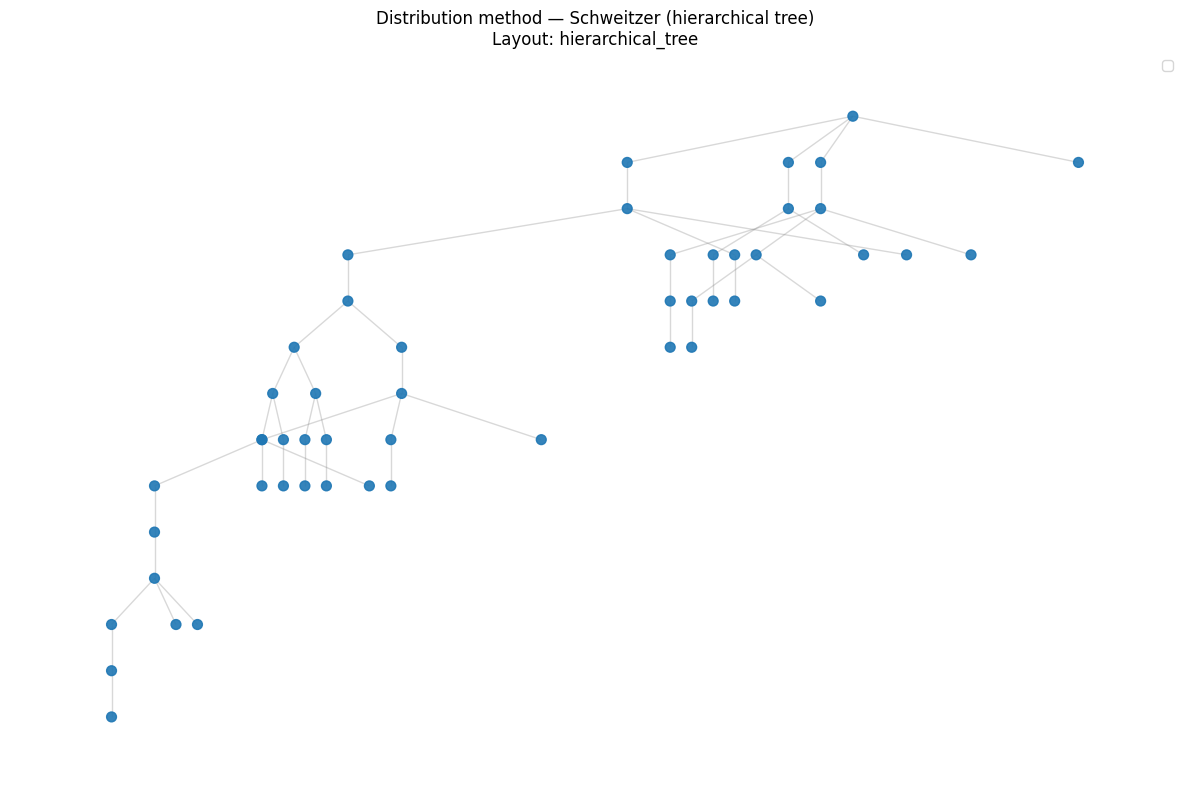

In [3]:
viz.plot_grid(G_dist, layout='hierarchical_tree',
              title='Distribution method — Schweitzer (hierarchical tree)',
              figsize=(12, 8))

## 2  Transmission-specific method (CLC)

The CLC model is designed for **meshed** transmission grids. We apply it at distribution scale  
with a single voltage level, matching the node count and targeting a low average degree (≈ 2)  
and high diameter to mimic distribution-like sparsity.

Since CLC uses Chung-Lu random graphs, it can create **cycles** even at very low average degree.

In [4]:
# --- CLC topology (single voltage level, distribution-like parameters) ---
level_specs = [
    {'n': N_NODES, 'avg_k': 2.0, 'diam': 15, 'dist_type': 'dpl'},
]
connection_specs = {}  # single level → no inter-level transformers

configurator = InputConfigurator(seed=SEED)
params = configurator.create_params(level_specs, connection_specs)

trans_gen = PowerGridGenerator(seed=SEED)
G_trans = trans_gen.generate_grid(**params, keep_lcc=True)

print(f"Nodes: {G_trans.number_of_nodes()}, Edges: {G_trans.number_of_edges()}")
print(f"Is tree: {nx.is_tree(G_trans)}")
print(f"Is connected: {nx.is_connected(G_trans)}")
if nx.is_connected(G_trans):
    print(f"Diameter: {nx.diameter(G_trans)}")

Generating Level 0: DPL distribution (Avg=2.0)
--- Starting Generation for 1 Voltage Levels ---
Generating Level 0...
  -> Level 0 Complete. Nodes: 70, Edges: 50
Generating Transformer Connections...
Filtering for Largest Connected Component (LCC)...
  -> Kept 37 nodes (removed 33 isolated nodes)
Nodes: 37, Edges: 40
Is tree: False
Is connected: True
Diameter: 15


Calculating layout 'kamada_kawai'...


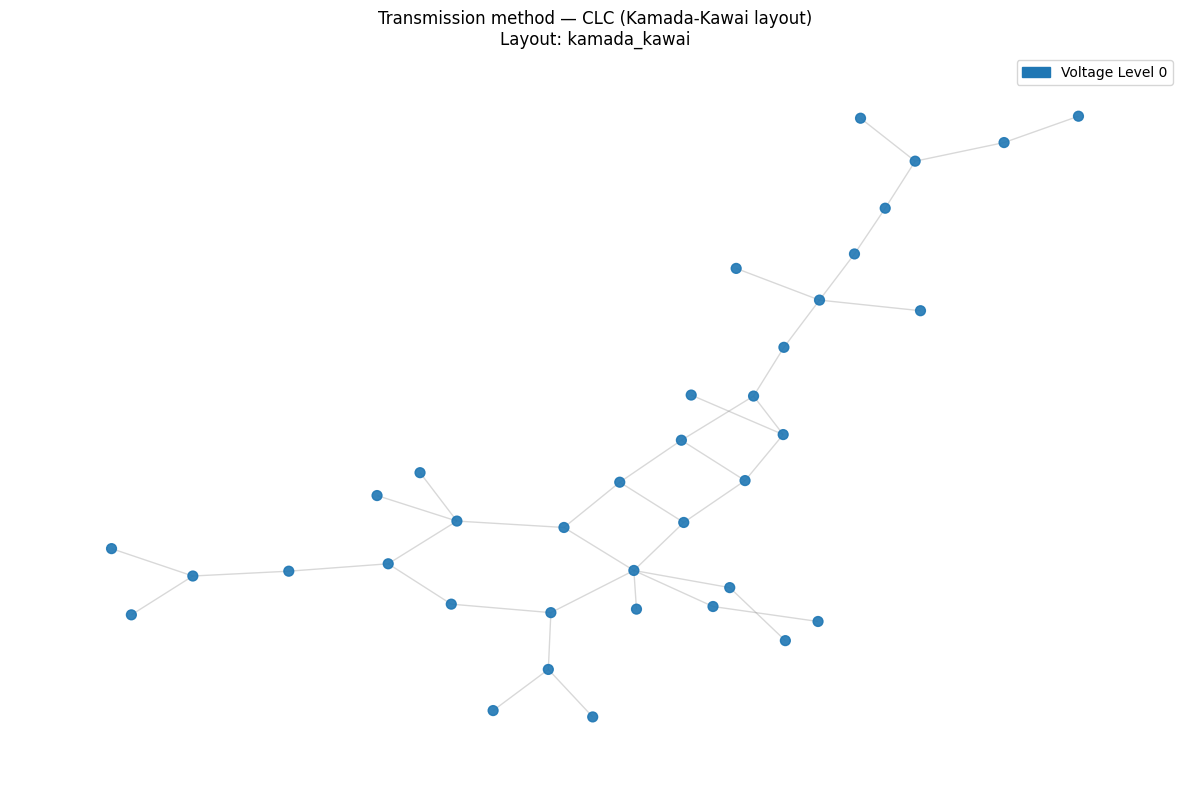

In [5]:
viz.plot_grid(G_trans, layout='kamada_kawai',
              title='Transmission method — CLC (Kamada-Kawai layout)',
              figsize=(12, 8))

## 3  Side-by-side structural comparison

In [6]:
# --- Metric table ---
comp = GraphComparator(G_trans, G_dist,
                       synth_label='CLC (transmission)',
                       ref_label='Schweitzer (distribution)')
comp.print_metric_comparison(title='TOPOLOGY COMPARISON')


TOPOLOGY COMPARISON
            Metric CLC (transmission) Schweitzer (distribution)
             Nodes                 37                        50
             Edges                 40                        49
           Density           0.060060                  0.040000
        Connected?                Yes                       Yes
    Diameter (LCC)                 15                        18
Avg Path Len (LCC)             5.8318                    7.4433
    Avg Clustering             0.0000                    0.0000
      Transitivity             0.0000                    0.0000



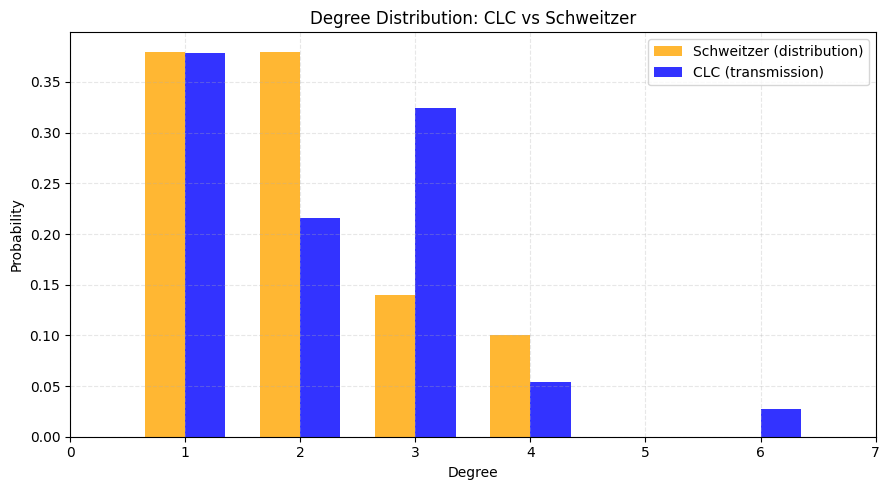

In [7]:
# --- Degree distribution comparison ---
comp.plot_degree_comparison(
    log_scale=False,
    title='Degree Distribution: CLC vs Schweitzer',
    fig_size=(9, 5),
)

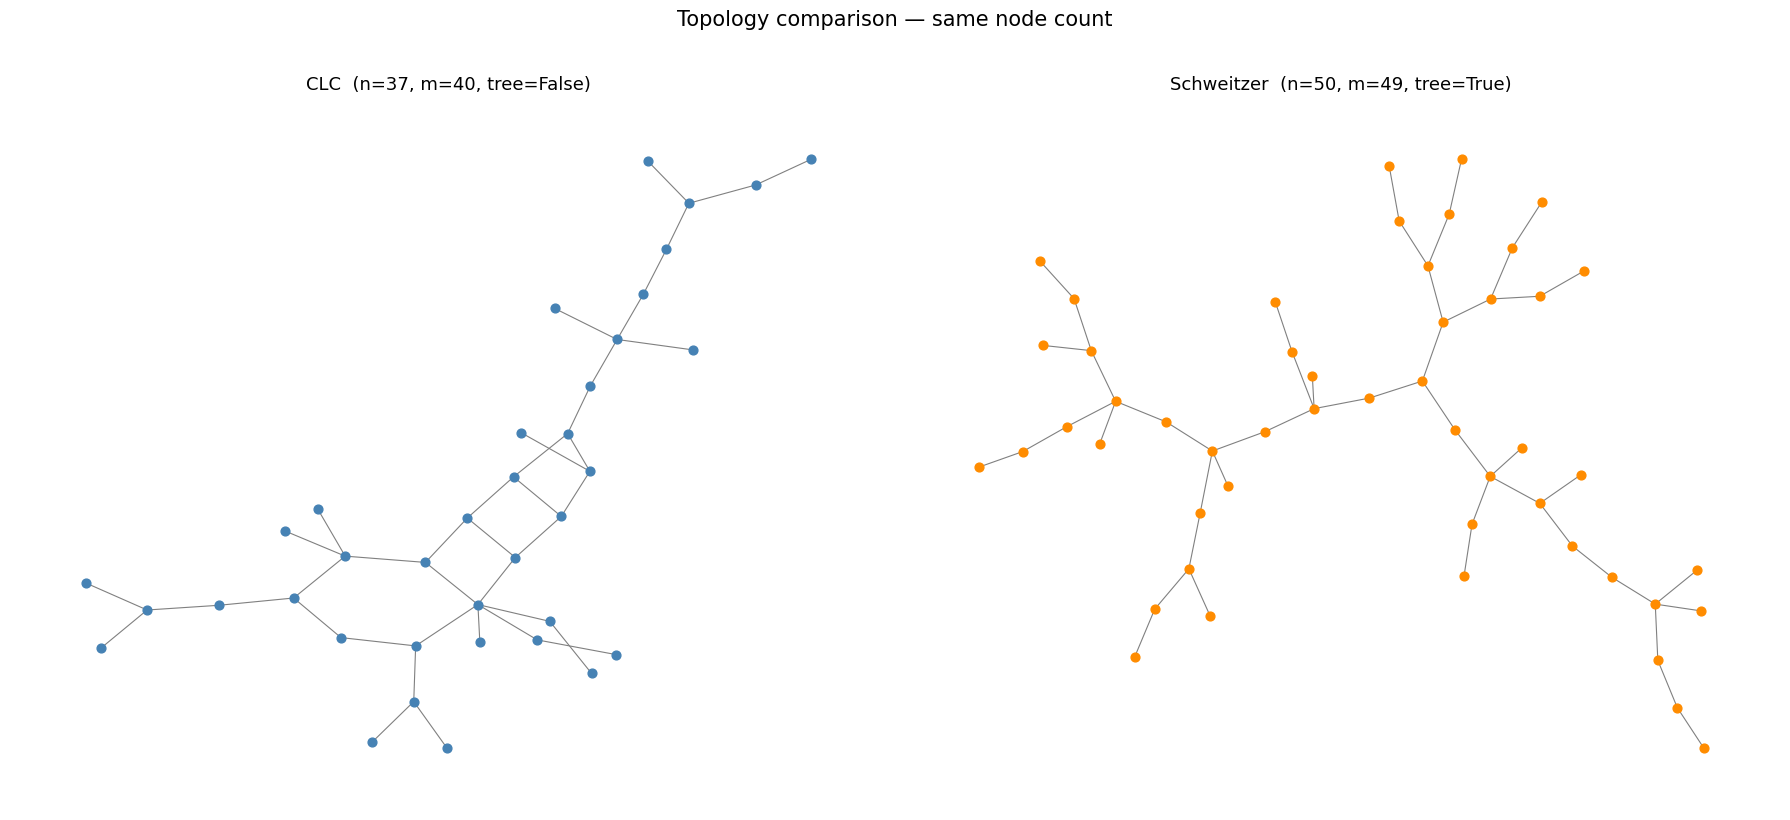

In [8]:
# --- Visual side-by-side ---
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# CLC
ax = axes[0]
pos_clc = nx.kamada_kawai_layout(G_trans)
nx.draw_networkx(G_trans, pos=pos_clc, ax=ax, node_size=40,
                 with_labels=False, node_color='steelblue', edge_color='gray', width=0.8)
ax.set_title(f'CLC  (n={G_trans.number_of_nodes()}, m={G_trans.number_of_edges()}, '
             f'tree={nx.is_tree(G_trans)})', fontsize=13)
ax.axis('off')

# Schweitzer
ax = axes[1]
pos_sw = nx.kamada_kawai_layout(G_dist)
nx.draw_networkx(G_dist, pos=pos_sw, ax=ax, node_size=40,
                 with_labels=False, node_color='darkorange', edge_color='gray', width=0.8)
ax.set_title(f'Schweitzer  (n={G_dist.number_of_nodes()}, m={G_dist.number_of_edges()}, '
             f'tree={G_dist.is_radial})', fontsize=13)
ax.axis('off')

fig.suptitle('Topology comparison — same node count', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

## 4  Hop-distance analysis

One key structural difference: the Schweitzer method explicitly assigns hop distances from a  
Negative Binomial distribution, creating a well-defined hierarchical depth structure.  
The CLC model has no notion of hop layers — we compute BFS depth from an arbitrary root for comparison.

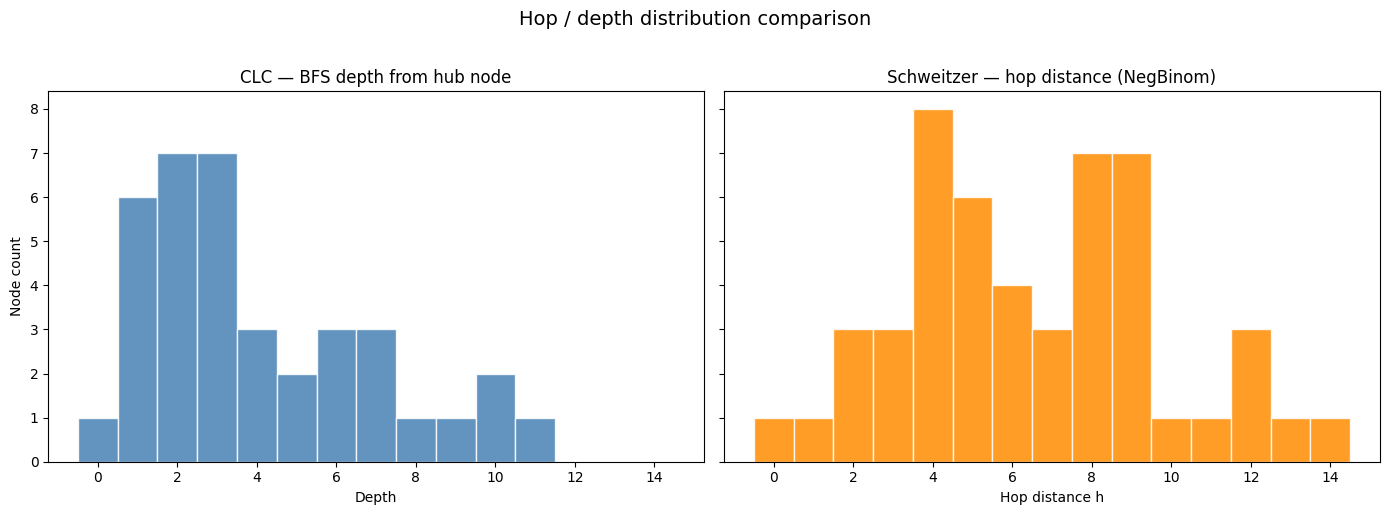

In [9]:
# --- Hop / BFS-depth distributions ---

# Schweitzer: explicit hop attribute
hop_dist = [G_dist.nodes[n].get('h', 0) for n in G_dist.nodes()]

# CLC: BFS from a high-degree node (proxy root)
root_clc = max(G_trans.nodes(), key=lambda n: G_trans.degree(n))
bfs_depth = nx.single_source_shortest_path_length(G_trans, root_clc)
hop_clc = list(bfs_depth.values())

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

max_h = max(max(hop_clc), max(hop_dist))
bins = np.arange(0, max_h + 2) - 0.5

axes[0].hist(hop_clc, bins=bins, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title('CLC — BFS depth from hub node', fontsize=12)
axes[0].set_xlabel('Depth')
axes[0].set_ylabel('Node count')

axes[1].hist(hop_dist, bins=bins, color='darkorange', edgecolor='white', alpha=0.85)
axes[1].set_title('Schweitzer — hop distance (NegBinom)', fontsize=12)
axes[1].set_xlabel('Hop distance h')

fig.suptitle('Hop / depth distribution comparison', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 5  Ensemble comparison

Generate multiple topologies with each method and compare aggregate statistics.

In [10]:
import io, contextlib

N_SAMPLES = 20

clc_stats = {'nodes': [], 'edges': [], 'is_tree': [], 'diameter': [], 'avg_degree': []}
sw_stats  = {'nodes': [], 'edges': [], 'is_tree': [], 'diameter': [], 'avg_degree': []}

for i in range(N_SAMPLES):
    seed_i = SEED + i

    # CLC (suppress verbose "Generating Level ..." output)
    with contextlib.redirect_stdout(io.StringIO()):
        cfg = InputConfigurator(seed=seed_i)
        p = cfg.create_params(level_specs, connection_specs)
        g = PowerGridGenerator(seed=seed_i)
        G_c = g.generate_grid(**p, keep_lcc=True)
    clc_stats['nodes'].append(G_c.number_of_nodes())
    clc_stats['edges'].append(G_c.number_of_edges())
    clc_stats['is_tree'].append(nx.is_tree(G_c))
    clc_stats['avg_degree'].append(np.mean([d for _, d in G_c.degree()]))
    if nx.is_connected(G_c):
        clc_stats['diameter'].append(nx.diameter(G_c))
    else:
        lcc = G_c.subgraph(max(nx.connected_components(G_c), key=len)).copy()
        clc_stats['diameter'].append(nx.diameter(lcc))

    # Schweitzer
    dg = SchweetzerFeederGenerator(seed=seed_i)
    G_s = dg.generate_feeder(
        n_nodes=N_NODES, total_load_mw=2.5, total_gen_mw=0.0,
        assign_cable_types=False, assign_cable_lengths=False,
    )
    sw_stats['nodes'].append(G_s.number_of_nodes())
    sw_stats['edges'].append(G_s.number_of_edges())
    sw_stats['is_tree'].append(nx.is_tree(G_s))
    sw_stats['avg_degree'].append(np.mean([d for _, d in G_s.degree()]))
    sw_stats['diameter'].append(nx.diameter(G_s))  # always connected tree

print(f"{'Metric':<20} {'CLC (mean±std)':<25} {'Schweitzer (mean±std)'}")
print('-' * 65)
for key in ['nodes', 'edges', 'diameter', 'avg_degree']:
    c = np.array(clc_stats[key], dtype=float)
    s = np.array(sw_stats[key], dtype=float)
    print(f"{key:<20} {c.mean():.2f} ± {c.std():.2f}{'':>8} {s.mean():.2f} ± {s.std():.2f}")
print(f"{'is_tree':<20} {np.mean(clc_stats['is_tree'])*100:.0f}%{'':>19} {np.mean(sw_stats['is_tree'])*100:.0f}%")

Metric               CLC (mean±std)            Schweitzer (mean±std)
-----------------------------------------------------------------
nodes                38.10 ± 6.65         50.00 ± 0.00
edges                40.95 ± 8.14         49.00 ± 0.00
diameter             15.55 ± 1.83         18.45 ± 2.09
avg_degree           2.14 ± 0.12         1.96 ± 0.00
is_tree              10%                    100%


## 7  Comparison against a real reference grid

We load a real distribution network from **pandapower** (CIGRE MV), extract its feeders,
and then generate synthetic topologies of matching size using both methods.

The comparison is three-way: **Reference** vs. **Schweitzer** vs. **CLC**.

In [11]:
import pandapower.networks as pn
from powergrid_synth.distribution import pandapower_to_feeders, feeder_summary

# Load CIGRE MV reference network
net_ref = pn.create_cigre_network_mv(with_der="all")
raw_feeders = pandapower_to_feeders(net_ref)
ref_feeders = [DistributionGrid.from_nx(f) for f in raw_feeders]

print(f"Reference network: CIGRE MV  ({net_ref.bus.shape[0]} buses)")
print(f"Extracted {len(ref_feeders)} feeder(s)\n")
for i, f in enumerate(ref_feeders):
    print(f"  Feeder {i}: {f.number_of_nodes()} nodes, {f.number_of_edges()} edges, "
          f"max_hop={f.max_hop}, radial={f.is_radial}")

Reference network: CIGRE MV  (15 buses)
Extracted 1 feeder(s)

  Feeder 0: 15 nodes, 17 edges, max_hop=6, radial=False


In [12]:
# Also try other reference networks
test_nets = {
    'CIGRE LV': pn.create_cigre_network_lv(),
    'CIGRE MV': pn.create_cigre_network_mv(with_der="all"),
    'Kerber Landnetz Freileitung': pn.create_kerber_landnetz_freileitung_1(),
    'Kerber Dorfnetz': pn.create_kerber_dorfnetz(),
    'Kerber Vorstadtnetz 1': pn.create_kerber_vorstadtnetz_kabel_1(),
}
print(f"{'Network':<35} {'Buses':>6} {'Feeders':>8} {'Nodes (largest)':>16} {'Radial':>8}")
print('-' * 80)
for name, net in test_nets.items():
    feeders = pandapower_to_feeders(net)
    if feeders:
        largest = max(feeders, key=lambda f: f.number_of_nodes())
        n = largest.number_of_nodes()
        radial = nx.is_tree(largest)
    else:
        n, radial = 0, '-'
    print(f"{name:<35} {net.bus.shape[0]:>6} {len(feeders):>8} {n:>16} {str(radial):>8}")

Network                              Buses  Feeders  Nodes (largest)   Radial
--------------------------------------------------------------------------------
CIGRE LV                                44        1               44     True
CIGRE MV                                15        1               15    False
Kerber Landnetz Freileitung             15        1               15     True
Kerber Dorfnetz                        116        1              116     True
Kerber Vorstadtnetz 1                  294        1              294     True


### 7.1  Reference: CIGRE LV (44 nodes, radial)

We extract the topology of the CIGRE LV feeder, then generate matching topologies with both methods.

In [13]:
# --- Extract CIGRE LV reference ---
net_lv = pn.create_cigre_network_lv()
lv_feeders = pandapower_to_feeders(net_lv)
ref_lv = DistributionGrid.from_nx(lv_feeders[0])

n_ref = ref_lv.number_of_nodes()
avg_k_ref = 2 * ref_lv.number_of_edges() / n_ref
diam_ref = nx.diameter(ref_lv)
print(f"Reference: n={n_ref}, edges={ref_lv.number_of_edges()}, avg_k={avg_k_ref:.2f}, "
      f"diameter={diam_ref}, max_hop={ref_lv.max_hop}, radial={ref_lv.is_radial}")

# --- Schweitzer topology (matching reference size) ---
sw_gen = SchweetzerFeederGenerator(seed=SEED)
G_sw_lv = DistributionGrid.from_nx(sw_gen.generate_feeder(
    n_nodes=n_ref, total_load_mw=0.5, assign_cable_types=False, assign_cable_lengths=False
))
print(f"\nSchweitzer: n={G_sw_lv.number_of_nodes()}, edges={G_sw_lv.number_of_edges()}, "
      f"diameter={nx.diameter(G_sw_lv)}, max_hop={G_sw_lv.max_hop}, radial={G_sw_lv.is_radial}")

# --- CLC topology (matching reference size and structure) ---
cfg_lv = InputConfigurator(seed=SEED)
p_lv = cfg_lv.create_params(
    levels=[{'n': n_ref, 'avg_k': avg_k_ref, 'diam': diam_ref, 'dist_type': 'poisson'}],
    inter_connections={},
)
gen_lv = PowerGridGenerator(seed=SEED)
G_clc_lv = gen_lv.generate_grid(**p_lv, keep_lcc=True)
print(f"CLC:        n={G_clc_lv.number_of_nodes()}, edges={G_clc_lv.number_of_edges()}, "
      f"diameter={nx.diameter(G_clc_lv) if nx.is_connected(G_clc_lv) else 'N/A'}, "
      f"tree={nx.is_tree(G_clc_lv)}")

Reference: n=44, edges=43, avg_k=1.95, diameter=23, max_hop=12, radial=True

Schweitzer: n=44, edges=43, diameter=20, max_hop=13, radial=True
Generating Level 0: POISSON distribution (Avg=1.9545454545454546)
--- Starting Generation for 1 Voltage Levels ---
Generating Level 0...
  -> Level 0 Complete. Nodes: 53, Edges: 38
Generating Transformer Connections...
Filtering for Largest Connected Component (LCC)...
  -> Kept 38 nodes (removed 15 isolated nodes)
CLC:        n=38, edges=37, diameter=22, tree=True


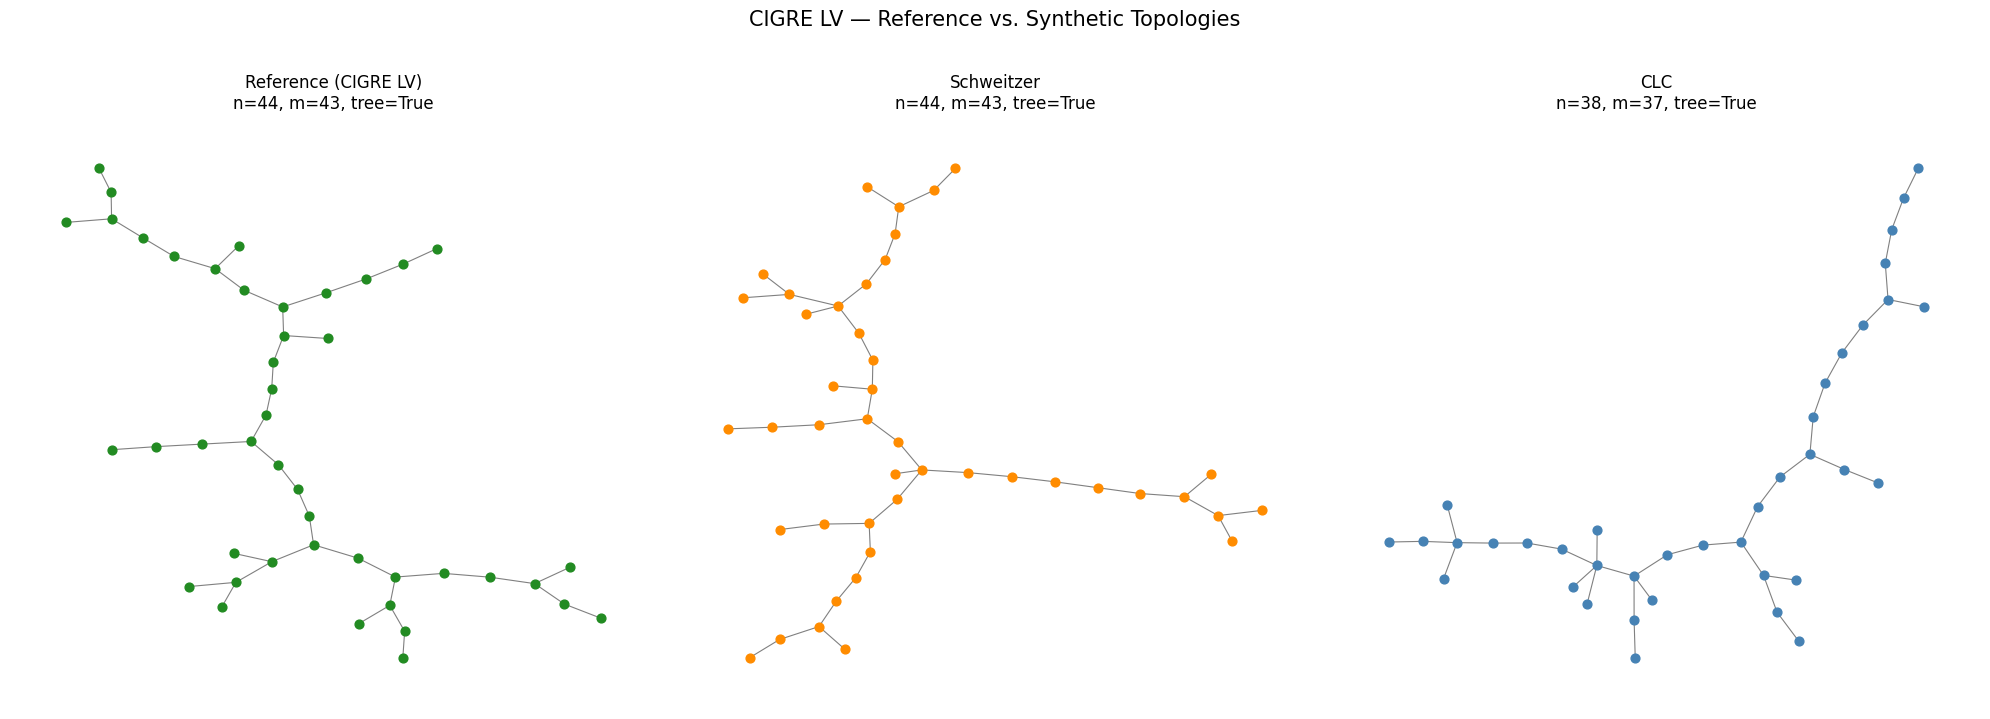

In [14]:
# --- Three-way visual comparison (CIGRE LV) ---
fig, axes = plt.subplots(1, 3, figsize=(20, 7))

for ax, G, color, title in zip(
    axes,
    [ref_lv, G_sw_lv, G_clc_lv],
    ['forestgreen', 'darkorange', 'steelblue'],
    ['Reference (CIGRE LV)', 'Schweitzer', 'CLC'],
):
    pos = nx.kamada_kawai_layout(G)
    nx.draw_networkx(G, pos=pos, ax=ax, node_size=40, with_labels=False,
                     node_color=color, edge_color='gray', width=0.8)
    n, m = G.number_of_nodes(), G.number_of_edges()
    ax.set_title(f'{title}\nn={n}, m={m}, tree={nx.is_tree(G)}', fontsize=12)
    ax.axis('off')

fig.suptitle('CIGRE LV — Reference vs. Synthetic Topologies', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

In [15]:
# --- Metric comparison: Schweitzer vs Reference ---
comp_sw = GraphComparator(G_sw_lv, ref_lv,
                          synth_label='Schweitzer', ref_label='CIGRE LV (ref)')
comp_sw.print_metric_comparison(title='SCHWEITZER vs REFERENCE (CIGRE LV)')

print()

# --- Metric comparison: CLC vs Reference ---
comp_clc = GraphComparator(G_clc_lv, ref_lv,
                           synth_label='CLC', ref_label='CIGRE LV (ref)')
comp_clc.print_metric_comparison(title='CLC vs REFERENCE (CIGRE LV)')


SCHWEITZER vs REFERENCE (CIGRE LV)
            Metric Schweitzer CIGRE LV (ref)
             Nodes         44             44
             Edges         43             43
           Density   0.045455       0.045455
        Connected?        Yes            Yes
    Diameter (LCC)         20             23
Avg Path Len (LCC)     8.3901         9.0433
    Avg Clustering     0.0000         0.0000
      Transitivity     0.0000         0.0000



CLC vs REFERENCE (CIGRE LV)
            Metric      CLC CIGRE LV (ref)
             Nodes       38             44
             Edges       37             43
           Density 0.052632       0.045455
        Connected?      Yes            Yes
    Diameter (LCC)       22             23
Avg Path Len (LCC)   7.9787         9.0433
    Avg Clustering   0.0000         0.0000
      Transitivity   0.0000         0.0000



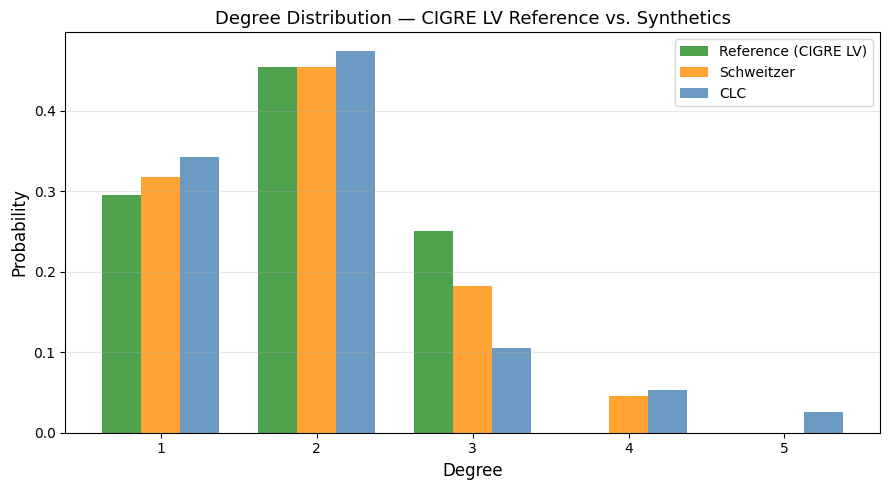

In [16]:
# --- Three-way degree distribution (CIGRE LV) ---
fig, ax = plt.subplots(figsize=(9, 5))

for G, label, color in [
    (ref_lv, 'Reference (CIGRE LV)', 'forestgreen'),
    (G_sw_lv, 'Schweitzer', 'darkorange'),
    (G_clc_lv, 'CLC', 'steelblue'),
]:
    degs = [d for _, d in G.degree()]
    vals, counts = np.unique(degs, return_counts=True)
    ax.bar(vals + {'forestgreen': -0.25, 'darkorange': 0.0, 'steelblue': 0.25}[color],
           counts / len(degs), width=0.25, color=color, alpha=0.8, label=label)

ax.set_xlabel('Degree', fontsize=12)
ax.set_ylabel('Probability', fontsize=12)
ax.set_title('Degree Distribution — CIGRE LV Reference vs. Synthetics', fontsize=13)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

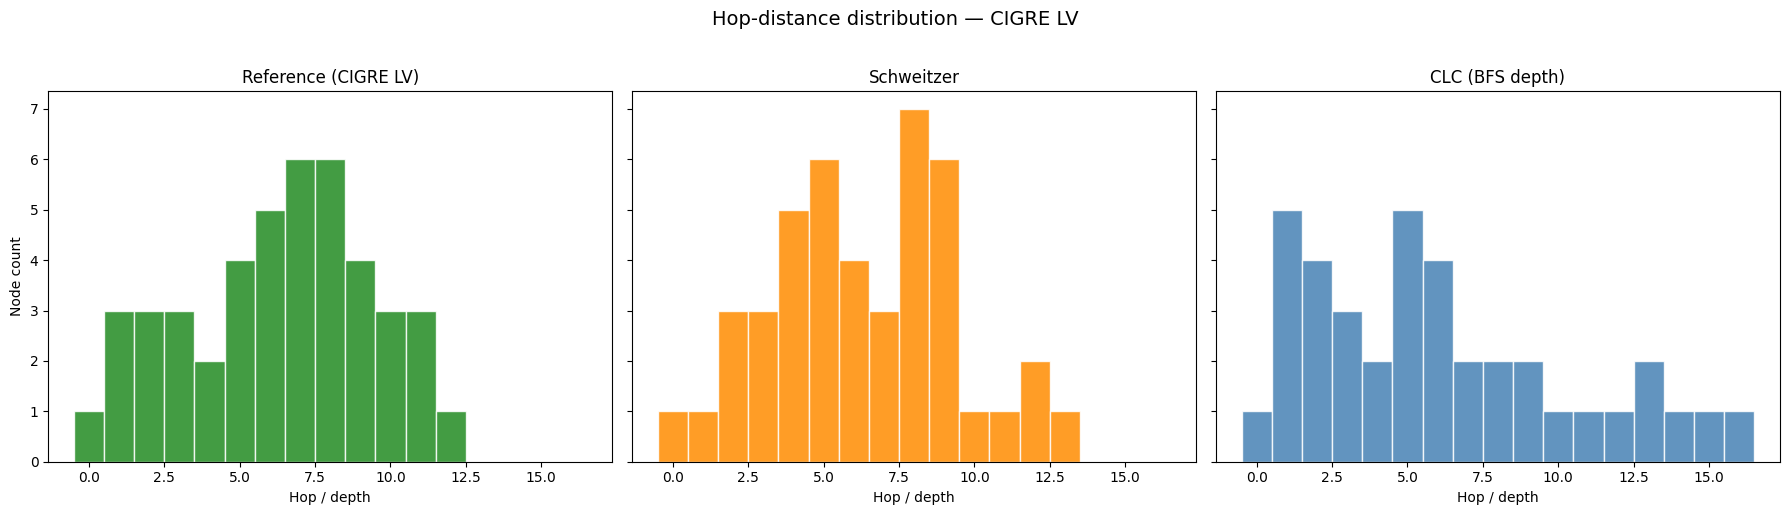

In [17]:
# --- Three-way hop / BFS-depth comparison (CIGRE LV) ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

# Reference: has explicit 'h' attribute from converter
hop_ref = [ref_lv.nodes[n].get('h', 0) for n in ref_lv.nodes()]

# Schweitzer: explicit 'h' attribute
hop_sw = [G_sw_lv.nodes[n].get('h', 0) for n in G_sw_lv.nodes()]

# CLC: BFS depth from highest-degree node
root_c = max(G_clc_lv.nodes(), key=lambda n: G_clc_lv.degree(n))
hop_clc_lv = list(nx.single_source_shortest_path_length(G_clc_lv, root_c).values())

max_h = max(max(hop_ref), max(hop_sw), max(hop_clc_lv))
bins = np.arange(0, max_h + 2) - 0.5

for ax, hops, color, title in zip(
    axes,
    [hop_ref, hop_sw, hop_clc_lv],
    ['forestgreen', 'darkorange', 'steelblue'],
    ['Reference (CIGRE LV)', 'Schweitzer', 'CLC (BFS depth)'],
):
    ax.hist(hops, bins=bins, color=color, edgecolor='white', alpha=0.85)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Hop / depth')
axes[0].set_ylabel('Node count')

fig.suptitle('Hop-distance distribution — CIGRE LV', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### 7.2  Reference: Kerber Dorfnetz (116 nodes, radial)

A larger reference network to see how both methods scale.

In [18]:
# --- Extract Kerber Dorfnetz reference ---
net_dorf = pn.create_kerber_dorfnetz()
dorf_feeders = pandapower_to_feeders(net_dorf)
ref_dorf = DistributionGrid.from_nx(dorf_feeders[0])

n_d = ref_dorf.number_of_nodes()
avg_k_d = 2 * ref_dorf.number_of_edges() / n_d
diam_d = nx.diameter(ref_dorf)
print(f"Reference: n={n_d}, edges={ref_dorf.number_of_edges()}, avg_k={avg_k_d:.2f}, "
      f"diameter={diam_d}, max_hop={ref_dorf.max_hop}, radial={ref_dorf.is_radial}")

# --- Schweitzer topology ---
sw_gen2 = SchweetzerFeederGenerator(seed=SEED)
G_sw_dorf = DistributionGrid.from_nx(sw_gen2.generate_feeder(
    n_nodes=n_d, total_load_mw=1.0, assign_cable_types=False, assign_cable_lengths=False
))
print(f"\nSchweitzer: n={G_sw_dorf.number_of_nodes()}, edges={G_sw_dorf.number_of_edges()}, "
      f"diameter={nx.diameter(G_sw_dorf)}, max_hop={G_sw_dorf.max_hop}, radial={G_sw_dorf.is_radial}")

# --- CLC topology ---
cfg_d = InputConfigurator(seed=SEED)
p_d = cfg_d.create_params(
    levels=[{'n': n_d, 'avg_k': avg_k_d, 'diam': diam_d, 'dist_type': 'poisson'}],
    inter_connections={},
)
gen_d = PowerGridGenerator(seed=SEED)
G_clc_dorf = gen_d.generate_grid(**p_d, keep_lcc=True)
n_clc = G_clc_dorf.number_of_nodes()
m_clc = G_clc_dorf.number_of_edges()
is_tree_clc = nx.is_tree(G_clc_dorf)
diam_clc = nx.diameter(G_clc_dorf) if nx.is_connected(G_clc_dorf) else 'N/A'
print(f"CLC:        n={n_clc}, edges={m_clc}, diameter={diam_clc}, tree={is_tree_clc}")

Reference: n=116, edges=115, avg_k=1.98, diameter=30, max_hop=18, radial=True

Schweitzer: n=116, edges=115, diameter=29, max_hop=17, radial=True
Generating Level 0: POISSON distribution (Avg=1.9827586206896552)
--- Starting Generation for 1 Voltage Levels ---
Generating Level 0...
  -> Level 0 Complete. Nodes: 137, Edges: 112
Generating Transformer Connections...
Filtering for Largest Connected Component (LCC)...
  -> Kept 94 nodes (removed 43 isolated nodes)
CLC:        n=94, edges=107, diameter=29, tree=False


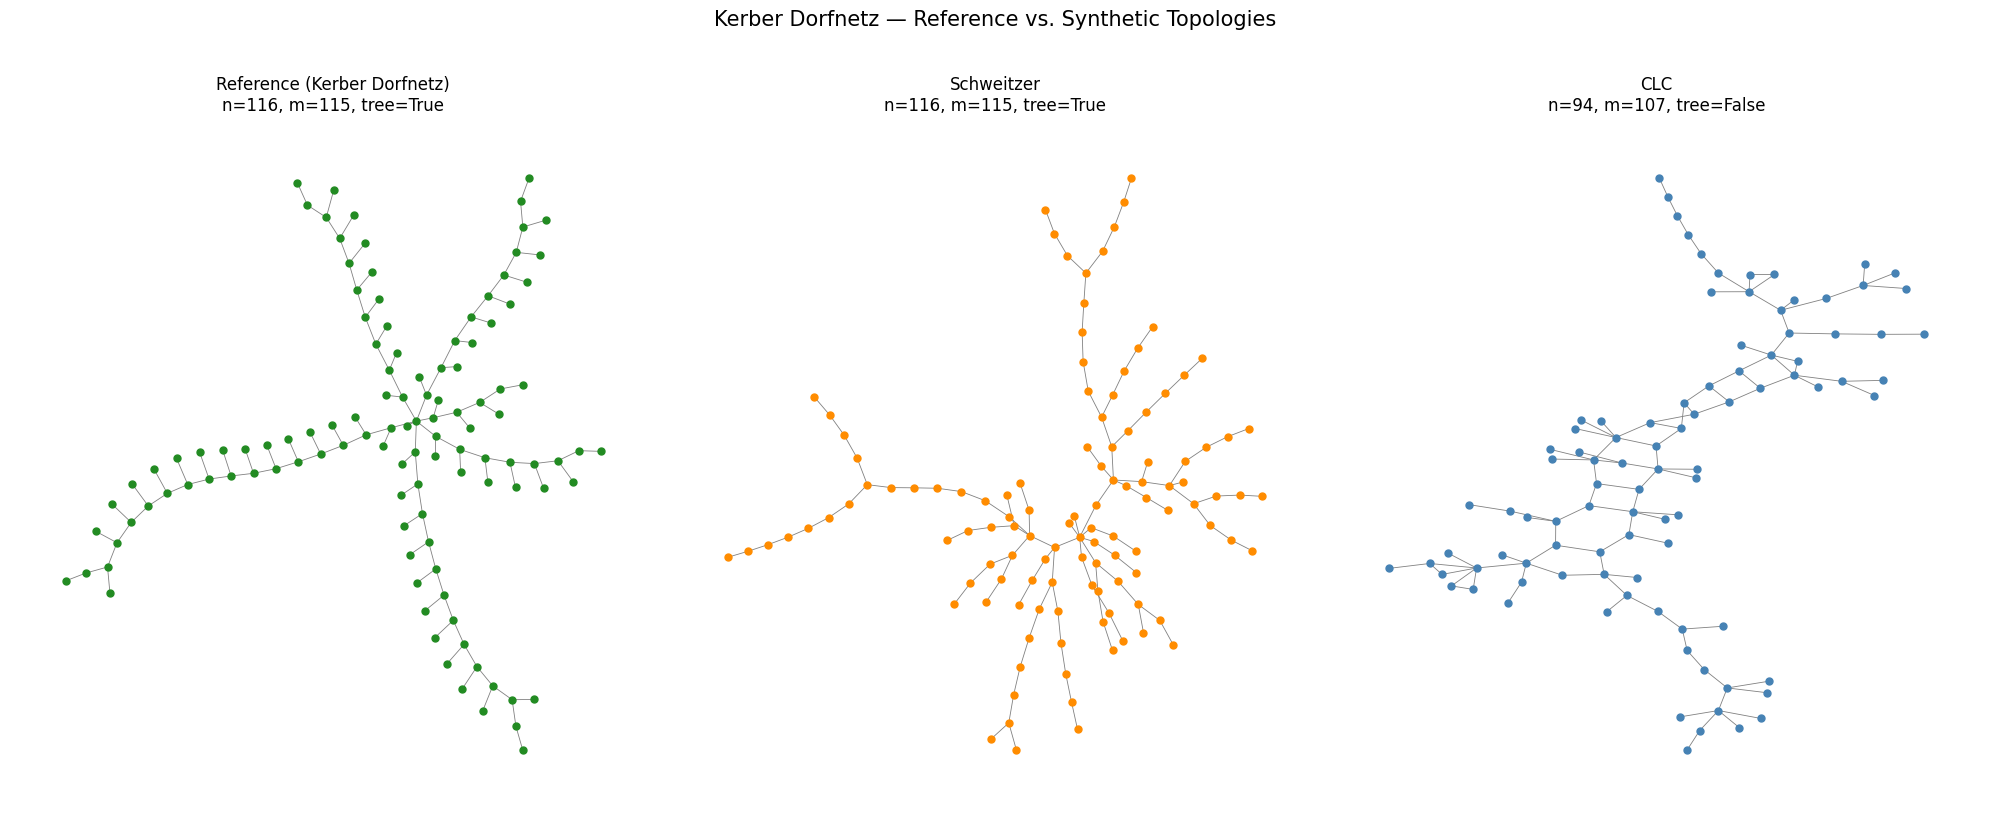

In [19]:
# --- Three-way visual comparison (Kerber Dorfnetz) ---
fig, axes = plt.subplots(1, 3, figsize=(20, 8))

for ax, G, color, title in zip(
    axes,
    [ref_dorf, G_sw_dorf, G_clc_dorf],
    ['forestgreen', 'darkorange', 'steelblue'],
    ['Reference (Kerber Dorfnetz)', 'Schweitzer', 'CLC'],
):
    pos = nx.kamada_kawai_layout(G)
    nx.draw_networkx(G, pos=pos, ax=ax, node_size=25, with_labels=False,
                     node_color=color, edge_color='gray', width=0.6)
    n, m = G.number_of_nodes(), G.number_of_edges()
    ax.set_title(f'{title}\nn={n}, m={m}, tree={nx.is_tree(G)}', fontsize=12)
    ax.axis('off')

fig.suptitle('Kerber Dorfnetz — Reference vs. Synthetic Topologies', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

In [20]:
# --- Metric comparison (Kerber Dorfnetz) ---
comp_sw2 = GraphComparator(G_sw_dorf, ref_dorf,
                           synth_label='Schweitzer', ref_label='Kerber Dorfnetz (ref)')
comp_sw2.print_metric_comparison(title='SCHWEITZER vs REFERENCE (Kerber Dorfnetz)')
print()
comp_clc2 = GraphComparator(G_clc_dorf, ref_dorf,
                            synth_label='CLC', ref_label='Kerber Dorfnetz (ref)')
comp_clc2.print_metric_comparison(title='CLC vs REFERENCE (Kerber Dorfnetz)')


SCHWEITZER vs REFERENCE (Kerber Dorfnetz)
            Metric Schweitzer Kerber Dorfnetz (ref)
             Nodes        116                   116
             Edges        115                   115
           Density   0.017241              0.017241
        Connected?        Yes                   Yes
    Diameter (LCC)         29                    30
Avg Path Len (LCC)     9.6199               11.1649
    Avg Clustering     0.0000                0.0000
      Transitivity     0.0000                0.0000



CLC vs REFERENCE (Kerber Dorfnetz)
            Metric      CLC Kerber Dorfnetz (ref)
             Nodes       94                   116
             Edges      107                   115
           Density 0.024480              0.017241
        Connected?      Yes                   Yes
    Diameter (LCC)       29                    30
Avg Path Len (LCC)  10.0304               11.1649
    Avg Clustering   0.0720                0.0000
      Transitivity   0.0536                0.0000



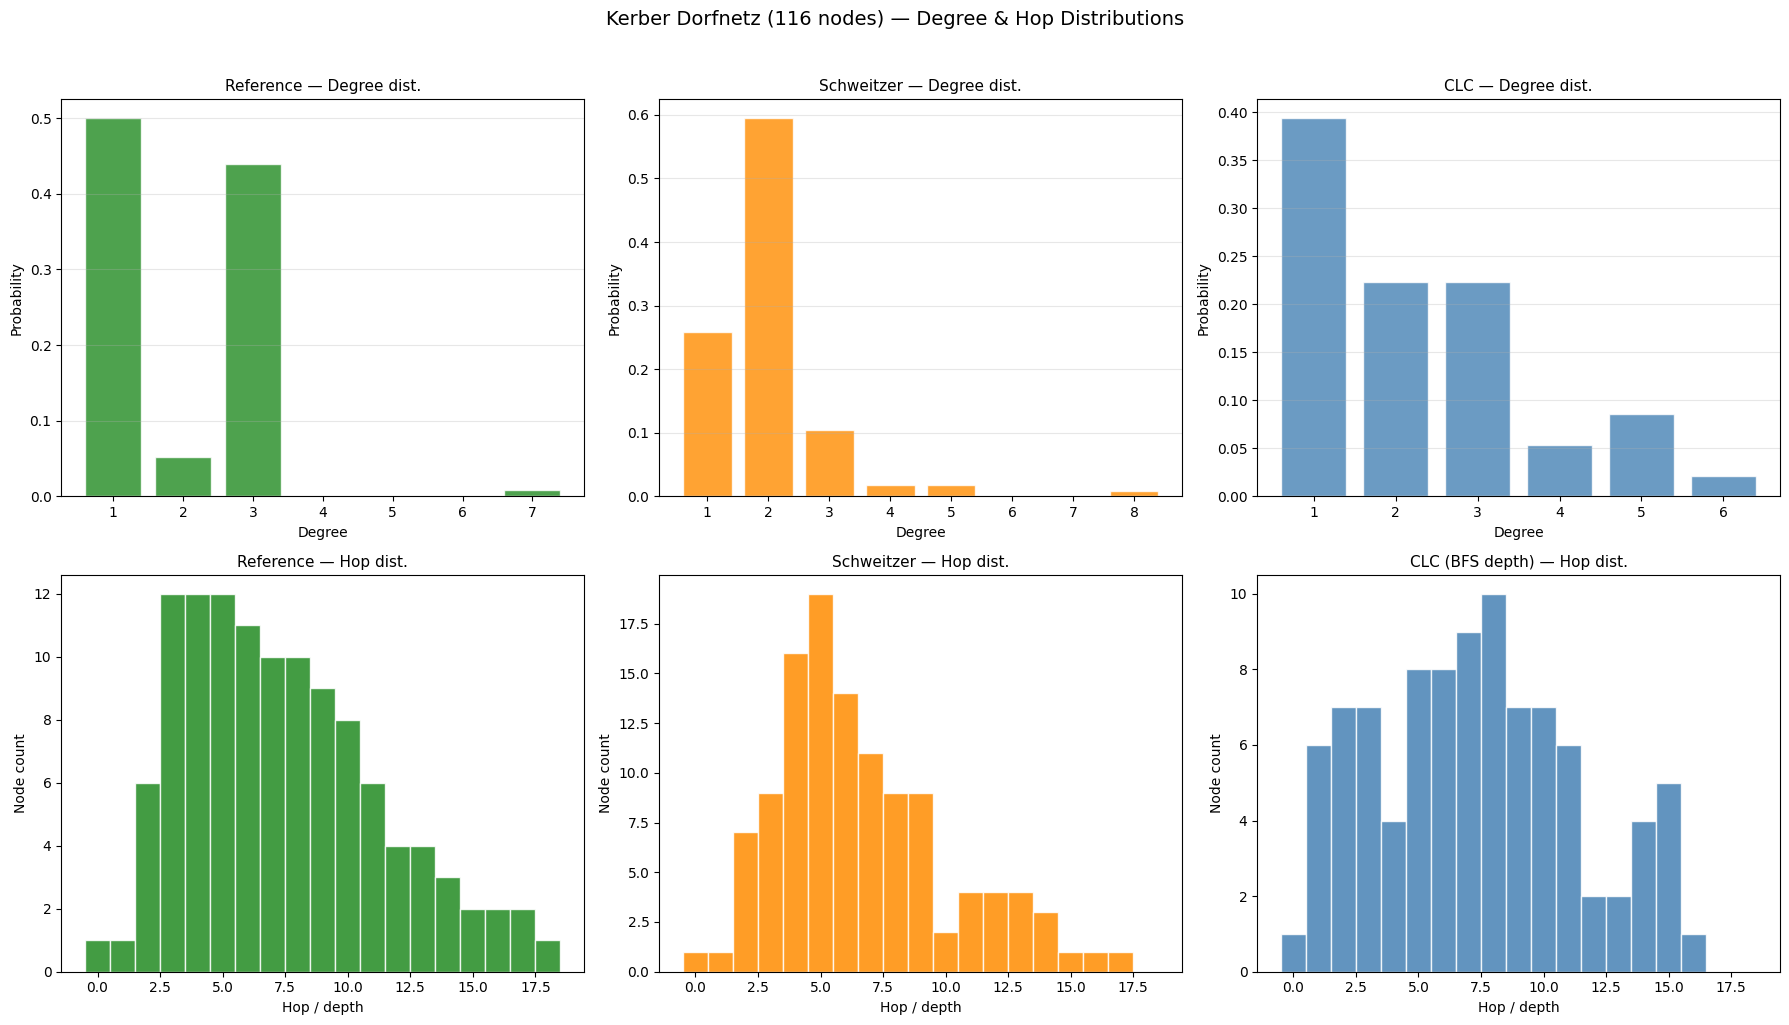

In [21]:
# --- Three-way degree + hop comparison (Kerber Dorfnetz) ---
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Row 1: Degree distributions
for ax, G, color, title in zip(
    axes[0],
    [ref_dorf, G_sw_dorf, G_clc_dorf],
    ['forestgreen', 'darkorange', 'steelblue'],
    ['Reference', 'Schweitzer', 'CLC'],
):
    degs = [d for _, d in G.degree()]
    vals, counts = np.unique(degs, return_counts=True)
    ax.bar(vals, counts / len(degs), color=color, alpha=0.8, edgecolor='white')
    ax.set_title(f'{title} — Degree dist.', fontsize=11)
    ax.set_xlabel('Degree')
    ax.set_ylabel('Probability')
    ax.grid(axis='y', alpha=0.3)

# Row 2: Hop / BFS-depth
hop_ref_d = [ref_dorf.nodes[n].get('h', 0) for n in ref_dorf.nodes()]
hop_sw_d = [G_sw_dorf.nodes[n].get('h', 0) for n in G_sw_dorf.nodes()]
root_cd = max(G_clc_dorf.nodes(), key=lambda n: G_clc_dorf.degree(n))
hop_clc_d = list(nx.single_source_shortest_path_length(G_clc_dorf, root_cd).values())

max_hd = max(max(hop_ref_d), max(hop_sw_d), max(hop_clc_d))
bins_d = np.arange(0, max_hd + 2) - 0.5

for ax, hops, color, title in zip(
    axes[1],
    [hop_ref_d, hop_sw_d, hop_clc_d],
    ['forestgreen', 'darkorange', 'steelblue'],
    ['Reference', 'Schweitzer', 'CLC (BFS depth)'],
):
    ax.hist(hops, bins=bins_d, color=color, edgecolor='white', alpha=0.85)
    ax.set_title(f'{title} — Hop dist.', fontsize=11)
    ax.set_xlabel('Hop / depth')
    ax.set_ylabel('Node count')

fig.suptitle('Kerber Dorfnetz (116 nodes) — Degree & Hop Distributions', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 8  Observations

### Synthetic-only comparison (§1–6)

| Aspect | CLC (transmission) | Schweitzer (distribution) |
|---|---|---|
| **Structure** | Meshed — cycles present even at low avg degree | Strictly radial (tree) — guaranteed |
| **Degree distribution** | Configurable (power-law, log-normal, Poisson) | Bimodal Gamma with hop-dependent clipping |
| **Depth structure** | No explicit hop/layer concept | Explicit Neg. Binomial hop assignment |
| **Diameter** | Tunable, typically moderate | Emerges from hop distribution — typically large |
| **Node preservation** | Loses nodes to LCC filtering at low density | Always preserves the requested node count |
| **Design intent** | Multi-level, meshed transmission grids | Single-feeder, radial distribution grids |

### Reference grid comparison (§7)

| Metric | CIGRE LV (44 nodes) | Kerber Dorfnetz (116 nodes) |
|---|---|---|
| **Schweitzer — node match** | 44/44 (100%) | 116/116 (100%) |
| **CLC — node match** | 38/44 (86%) | 94/116 (81%) |
| **Schweitzer — tree?** | Yes | Yes |
| **CLC — tree?** | Yes (by chance) | No (clustering = 0.072) |
| **Schweitzer — hop shape** | Bell-shaped, close to reference | Bell-shaped, close to reference |
| **CLC — BFS depth shape** | Front-heavy, poor match | Flatter, poor match |

**Conclusion**: The CLC method is not suitable for generating realistic radial distribution feeders.
Even with tree-like parameters (avg degree ≈ 2), it produces topologies that:
1. **Lose nodes** due to LCC filtering (Chung-Lu can create isolated components)
2. **Create cycles** at larger scales, violating the radial structure of real feeders
3. **Lack hierarchical depth** — the BFS-depth distribution does not match the characteristic
   bell-shaped hop profile of real distribution grids

The Schweitzer method is purpose-built for this task and consistently produces trees
with correct node count, radial structure, and hop distributions that match real data.